# Real daily SPY data audit

Validate the real daily OHLCV source before evaluating any limit-order rule. This notebook contains no synthetic or monthly Shiller path.

In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px

from retail_sp500.daily_data import daily_data_summary, load_or_fetch_twelve_data_daily

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Load validated daily sessions

The first run requires `TWELVE_DATA_API_KEY`; subsequent runs use the ignored local CSV cache. Set `REFRESH = True` to update it.

In [2]:
SYMBOL = "SPY"
START_DATE = "2007-06-01"
CACHE_PATH = Path("data/processed/spy_daily_1day.csv")
REFRESH = False

daily = load_or_fetch_twelve_data_daily(
    os.getenv("TWELVE_DATA_API_KEY"),
    cache_path=CACHE_PATH,
    refresh=REFRESH,
    symbol=SYMBOL,
    start_date=START_DATE,
)

source = daily_data_summary(daily, symbol=SYMBOL)
print(source)
assert source["interval"] == "1day"
assert daily.index.max() <= pd.Timestamp.today().normalize()
daily.tail()

{'source': 'Twelve Data', 'symbol': 'SPY', 'interval': '1day', 'start': '2007-06-01', 'end': '2026-07-14', 'sessions': 4809}


,open,high,low,close,volume
date,,,,,
2026-07-08,743.159970,746.150020,739.510010,745.400020,43767400
2026-07-09,747.349980,751.969970,745.590030,751.710020,41441700
2026-07-10,752.049988,755.419980,748.099976,754.950010,42191300
2026-07-13,752.469970,753.909970,748.000000,749.169980,44013600
2026-07-14,750.909970,753.299990,748.659970,751.830020,35135286


## Price history and session diagnostics

In [3]:
diagnostics = daily.assign(
    close_return=daily["close"].pct_change(),
    overnight_gap=daily["open"] / daily["close"].shift(1) - 1.0,
    intraday_low_from_previous_close=daily["low"] / daily["close"].shift(1) - 1.0,
    intraday_high_from_previous_close=daily["high"] / daily["close"].shift(1) - 1.0,
).dropna()

diagnostics[[
    "close_return",
    "overnight_gap",
    "intraday_low_from_previous_close",
    "intraday_high_from_previous_close",
]].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

,close_return,overnight_gap,intraday_low_from_previous_close,intraday_high_from_previous_close
count,"4,808.000000","4,808.000000","4,808.000000","4,808.000000"
mean,0.000408,0.000247,-0.006381,0.006339
std,0.012477,0.007546,0.010542,0.009447
min,-0.109424,-0.104485,-0.118669,-0.046116
1%,-0.035900,-0.022698,-0.044899,-0.011086
5%,-0.018510,-0.010800,-0.024475,-0.004007
10%,-0.012487,-0.006960,-0.017590,-0.001272
25%,-0.004288,-0.002592,-0.009520,0.001430
50%,0.000646,0.000523,-0.004140,0.004645
75%,0.005988,0.003461,-0.000512,0.009375


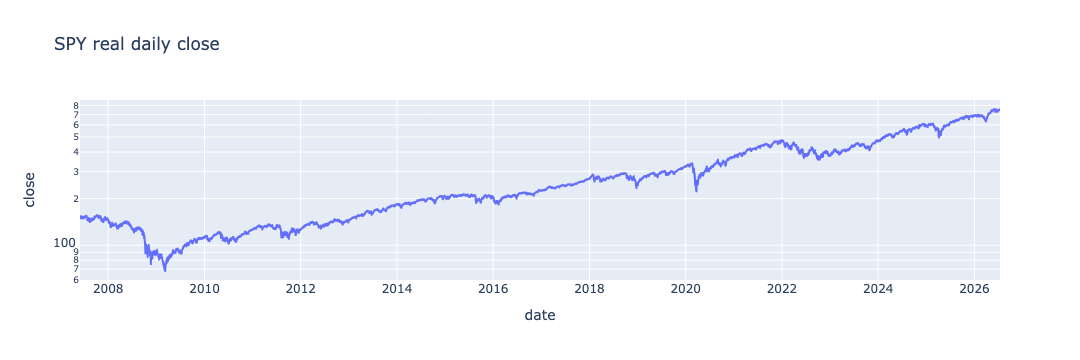

In [4]:
px.line(
    daily.reset_index(),
    x="date",
    y="close",
    log_y=True,
    title=f"{SYMBOL} real daily close",
).show()

## How far below the prior close does SPY trade?

This distribution is descriptive only. It does not account for missed rallies or delayed capital deployment.

In [5]:
dip_below_previous_close = (
    1.0 - diagnostics["low"] / diagnostics["close"].shift(1)
).dropna()

dip_below_previous_close.quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).rename("discount_touched")

0.100000   -0.002290
0.250000    0.000511
0.500000    0.004140
0.750000    0.009520
0.900000    0.017590
0.950000    0.024480
0.990000    0.044900
Name: discount_touched, dtype: float64

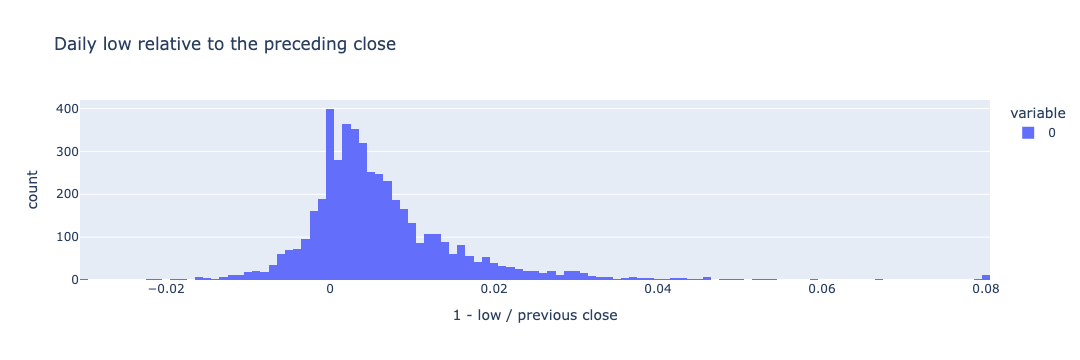

In [6]:
px.histogram(
    dip_below_previous_close.clip(lower=-0.03, upper=0.08),
    nbins=120,
    title="Daily low relative to the preceding close",
    labels={"value": "1 - low / previous close"},
).show()